In [3]:
import pandas as pd
full = pd.read_csv("full.csv")

In [4]:
full.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Corners_away,away_Possession,diff_goals_scored,diff_attempts_at_goal,diff_attempts_on_target,diff_conversion_rate,diff_attempts_inside_pa,diff_headed_attempts,diff_xG,diff_possession
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,46,8,31,10,9,31,8,5.62,2
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,37,0,-2,3,0,-1,-1,0.94,19
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,40,0,57,17,-9,39,8,5.28,13
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,10,27,8,24,11,10,30,8,4.38,25
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,28,49,-8,-57,-24,-2,-40,-5,-7.71,-18


In [5]:
full.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                104 non-null    int64  
 1   voteStatus                        104 non-null    str    
 2   stage                             104 non-null    str    
 3   roundName                         104 non-null    str    
 4   votingStartDate                   104 non-null    str    
 5   votingEndDate                     104 non-null    str    
 6   votingOpenedAt                    104 non-null    str    
 7   selectedFormation                 2 non-null      str    
 8   winners                           104 non-null    str    
 9   formations                        2 non-null      str    
 10  id.1                              104 non-null    int64  
 11  venueName                         104 non-null    str    
 12  venueCity          

Text(0, 0.5, 'Goals Scored')

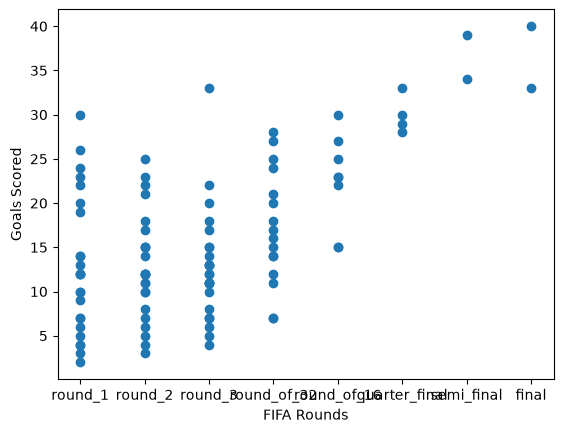

In [13]:
# x = roundName y=away_Goals & home_Goals
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.scatter(full["roundName"], (full["away_Goals"] + full["home_Goals"]))
plt.xlabel("FIFA Rounds")
plt.ylabel("Goals Scored")

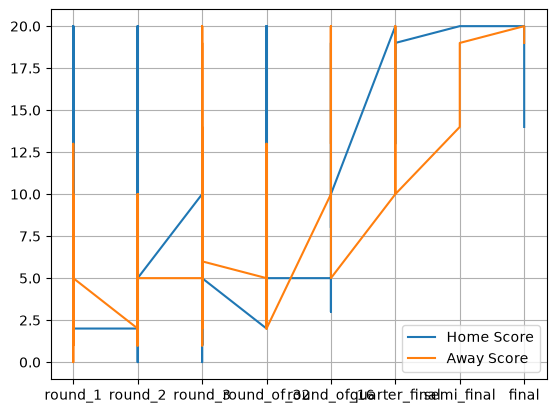

In [11]:
plt.plot(full['roundName'], full['home_Goals'], label='Home Score')
plt.plot(full['roundName'], full['away_Goals'], label='Away Score')
plt.grid(True)
plt.legend()

In [15]:
# 6. Build eight explanatory variables as "home minus away"

full["diff_goals_scored"] = full["home_Goals"] - full["away_Goals"]
full["diff_attempts_at_goal"] = full["home_Attempts_at_goal"] - full["away_Attempts_at_goal"]
full["diff_attempts_on_target"] = full["home_Attempts_on_target"] - full["away_Attempts_on_target"]
full["diff_conversion_rate"] = full["home_ConversionRate"] - full["away_ConversionRate"]
full["diff_attempts_inside_pa"] = full["home_Attempts_inside_PA"] - full["away_Attempts_inside_PA"]
full["diff_headed_attempts"] = full["home_Headed_attempts"] - full["away_Headed_attempts"]
full["diff_xG"] = full["home_xG"] - full["away_xG"]
full["diff_possession"] = full["home_Possession"] - full["away_Possession"]

feature_cols = [
    "diff_goals_scored",
    "diff_attempts_at_goal",
    "diff_attempts_on_target",
    "diff_conversion_rate",
    "diff_attempts_inside_pa",
    "diff_headed_attempts",
    "diff_xG",
    "diff_possession"
]

In [16]:
# 7. Final dataset: 104 rows, 8 features + target

final_df = full[["goal_diff"] + feature_cols].dropna()

print("\nFinal dataset shape:", final_df.shape)
print("\nFeature list:")
for c in feature_cols:
    print("-", c)

print("\nPreview of dataset:")
print(final_df.head())


Final dataset shape: (104, 9)

Feature list:
- diff_goals_scored
- diff_attempts_at_goal
- diff_attempts_on_target
- diff_conversion_rate
- diff_attempts_inside_pa
- diff_headed_attempts
- diff_xG
- diff_possession

Preview of dataset:
   goal_diff  diff_goals_scored  diff_attempts_at_goal  \
0          2                  8                     31   
1          1                  0                     -2   
2          0                  0                     57   
3          3                  8                     24   
4          0                 -8                    -57   

   diff_attempts_on_target  diff_conversion_rate  diff_attempts_inside_pa  \
0                       10                     9                       31   
1                        3                     0                       -1   
2                       17                    -9                       39   
3                       11                    10                       30   
4                      -24   

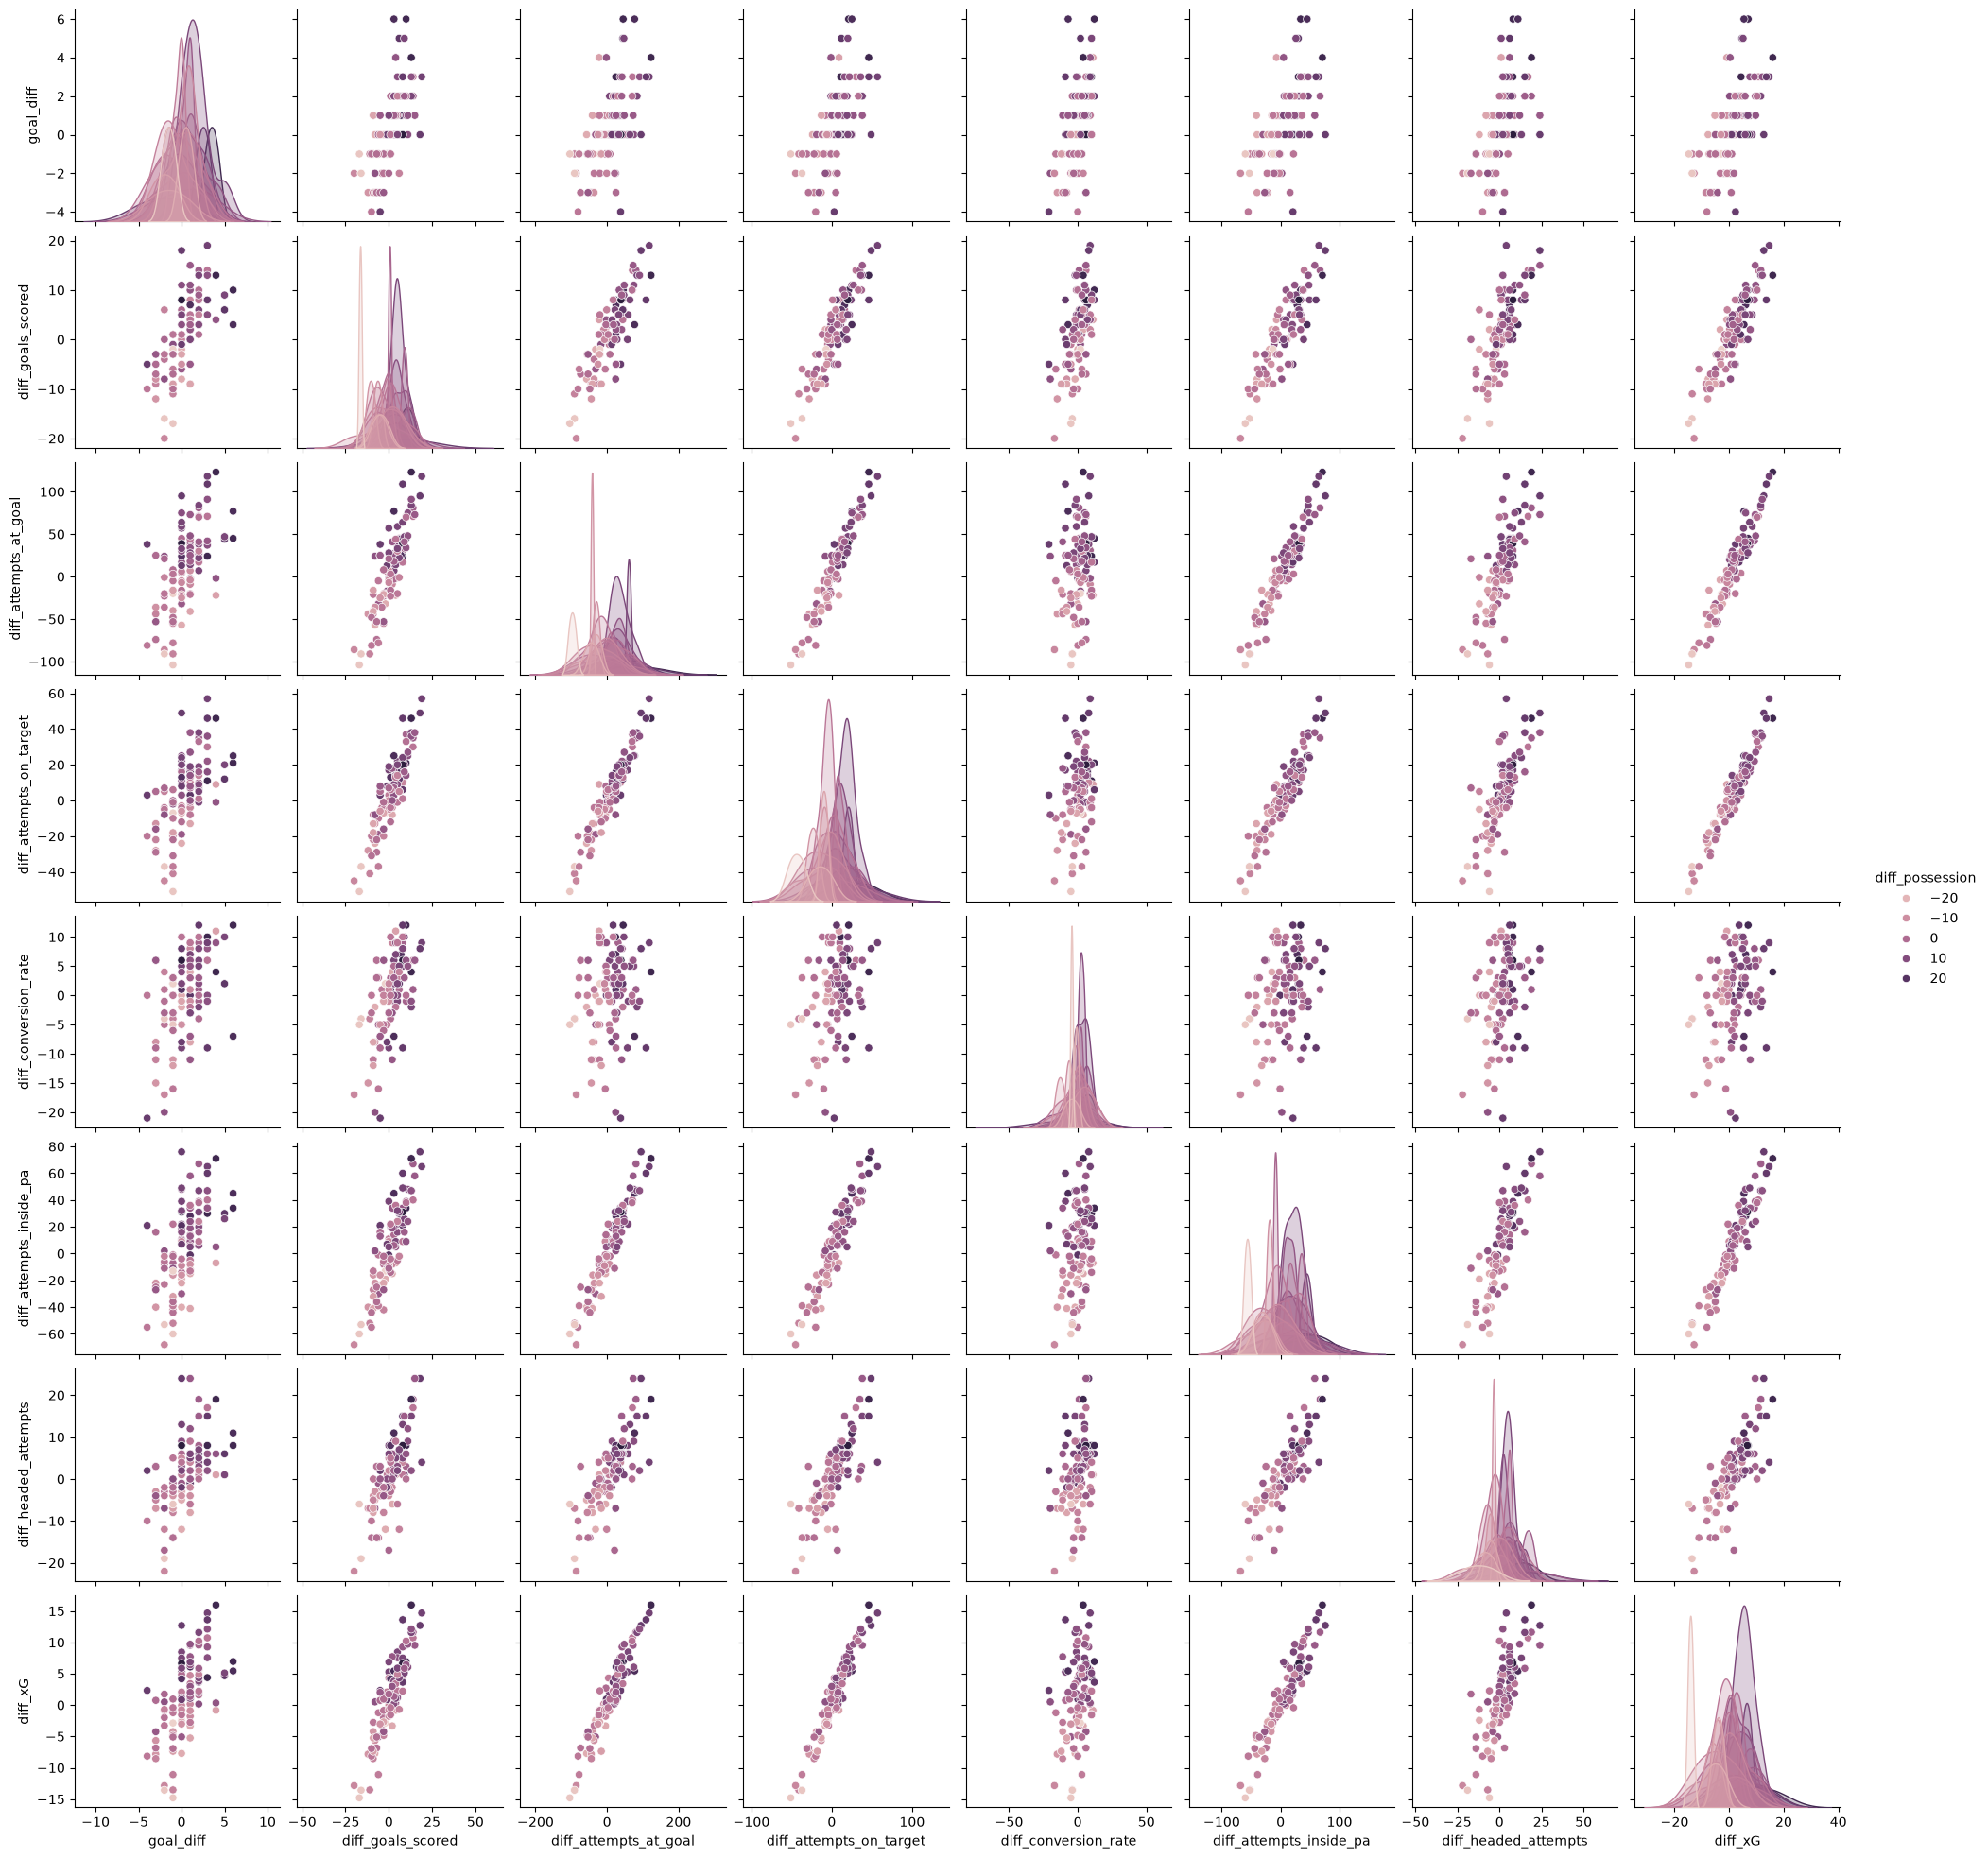

In [17]:
sns.pairplot(final_df, hue='diff_possession')